In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv(r"C:\Users\ADITYA GUPTA\Downloads\Data\DataCoSupplyChainDataset.csv", encoding='latin-1')

In [49]:
df.shape

(180519, 53)

In [50]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [51]:
df.isnull().sum().sort_values(ascending=False).head(5)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
dtype: int64

In [52]:
df.shape

(180519, 53)

In [53]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market',
    'Order Zipcode'
]
df = df.drop(columns=columns_to_drop)

df = df[df['Delivery Status'] != 'Shipping canceled']

for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

In [54]:
df.shape

(172765, 20)

In [55]:
df.isnull().sum().sort_values(ascending=False).head(5)

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64

In [56]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [57]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"{col}: {df[col].unique()}")
    print(df[col].value_counts())


Type: <StringArray>
['DEBIT', 'TRANSFER', 'CASH', 'PAYMENT']
Length: 4, dtype: str
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
Days for shipping (real): [3 5 4 2 0 6 1]
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64
Days for shipment (scheduled): [4 1 2 0]
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64
Sales per customer
122.839996     1215
124.790001     1198
106.589996     1197
127.389999     1195
114.389999     1193
               ... 
1939.989990       1
84.150002         1
298.769989        1
403.709992        1
474.760010        1
Name: count, Length: 2913, dtype: int64
Delivery Status: <StringArray>
['Advance shipping', 'Late delivery', 'Shipping on time']
Length: 3, dtype: str
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dt

In [58]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [59]:
df['Order_Processing_time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Days for shipment (scheduled)'] - df['Order_Processing_time']
df['is_delayed'] = df['Delay'] < 0
df['day'] = df['order date (DateOrders)'].dt.day
df['month'] = df['order date (DateOrders)'].dt.month
df['Order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order_Processing_time,Delay,day,month,Order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,-0.539716,15.739803,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-4.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,-1.000000,8.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,-1.000000,16.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,0.000000,23.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,2.000000,31.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,8.823467,3.405593,6.927276


In [60]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order_Processing_time', 'Delay', 'is_delayed', 'day',
       'month', 'Order_hour'],
      dtype='str')

In [61]:
df['is_delayed'].value_counts()

is_delayed
True     94523
False    78242
Name: count, dtype: int64

#visualization

In [62]:
df[['Order Profit Per Order']].head(5)

,Order Profit Per Order
0,91.250000
1,-249.089996
2,-247.779999
3,22.860001
4,134.210007


In [63]:
df['Profitability_Flag'] = np.where (df['Order Profit Per Order'] > 0, 'Profitable', np.where(df['Order Profit Per Order'] < 0, 'Unprofitable', 'Break-Even') )
df['Profitability_Flag'].value_counts()

Profitability_Flag
Profitable      139354
Unprofitable     32295
Break-Even        1116
Name: count, dtype: int64

In [64]:
df['Profitability_Flag'].value_counts(normalize=True)

Profitability_Flag
Profitable      0.80661
Unprofitable    0.18693
Break-Even      0.00646
Name: proportion, dtype: float64

ValueError: Invalid color lightred

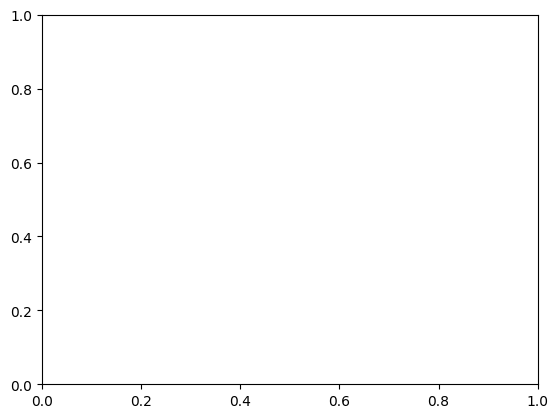

In [ ]:
#creating pi chart for profitability flag
profit_count = df['Profitability_Flag'].value_counts() * 100
profit_count.plot(kind='pie', autopct='%1.1f%%', startangle=20, colors=['lightblue', 'lightcoral', 'silver'], wedgeprops={'edgecolor': 'lightblue'})
plt.title('profitability flag distribution (%)')